# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [3]:
## Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier



# 1. Business Understanding
Goal: To build a machine learning classification model that predicts the likelihood of a diabetes diagnosis based on patient-reported symptoms and demographic data, enabling healthcare workers or patients themselves to perform a quick, low-cost preliminary risk assessment.



# 2. Data Understanding

## 2.1 Load dataset

In [4]:
## Read *.csv file into pandas DataFrame
FILE_PATH = r"C:\Users\denni\Downloads\early+stage+diabetes+risk+prediction+dataset\diabetes_data_upload.csv"
df = pd.read_csv(FILE_PATH)

## 2.2 Summary Statistics

In [5]:
## Understand the type of variable for each column
df.shape
df.dtypes

Age                   int64
Gender                  str
Polyuria                str
Polydipsia              str
sudden weight loss      str
weakness                str
Polyphagia              str
Genital thrush          str
visual blurring         str
Itching                 str
Irritability            str
delayed healing         str
partial paresis         str
muscle stiffness        str
Alopecia                str
Obesity                 str
class                   str
dtype: object

In [18]:
df.info

<bound method DataFrame.info of      Age  Gender Polyuria Polydipsia sudden weight loss weakness Polyphagia  \
0     40    Male       No        Yes                 No      Yes         No   
1     58    Male       No         No                 No      Yes         No   
2     41    Male      Yes         No                 No      Yes        Yes   
3     45    Male       No         No                Yes      Yes        Yes   
4     60    Male      Yes        Yes                Yes      Yes        Yes   
..   ...     ...      ...        ...                ...      ...        ...   
515   39  Female      Yes        Yes                Yes       No        Yes   
516   48  Female      Yes        Yes                Yes      Yes        Yes   
517   58  Female      Yes        Yes                Yes      Yes        Yes   
518   32  Female       No         No                 No      Yes         No   
519   42    Male       No         No                 No       No         No   

    Genital thrush 

In [6]:
## Check for missing data
df.isnull().sum()

Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

In [ ]:
## Describe data distribution
df.describe(include='all').round(2)

## 

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Age                 520 non-null    int64
 1   Gender              520 non-null    str  
 2   Polyuria            520 non-null    str  
 3   Polydipsia          520 non-null    str  
 4   sudden weight loss  520 non-null    str  
 5   weakness            520 non-null    str  
 6   Polyphagia          520 non-null    str  
 7   Genital thrush      520 non-null    str  
 8   visual blurring     520 non-null    str  
 9   Itching             520 non-null    str  
 10  Irritability        520 non-null    str  
 11  delayed healing     520 non-null    str  
 12  partial paresis     520 non-null    str  
 13  muscle stiffness    520 non-null    str  
 14  Alopecia            520 non-null    str  
 15  Obesity             520 non-null    str  
 16  class               520 non-null    str  
dtypes: int64

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

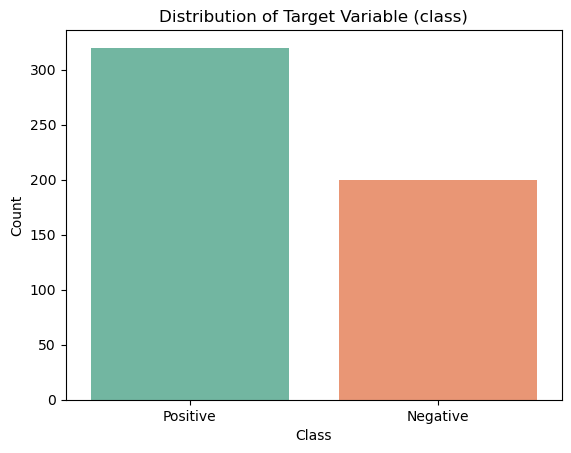

In [ ]:
## Understanding distribution of target
df['class'].value_counts()
df['class'].value_counts(normalize=True).round(3) * 100

sns.countplot(x='class', data=df, hue='class', palette='Set2', legend=False)
plt.title('Distribution of Target Variable (class)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


### 2.3.1.2 Understanding distribution of features

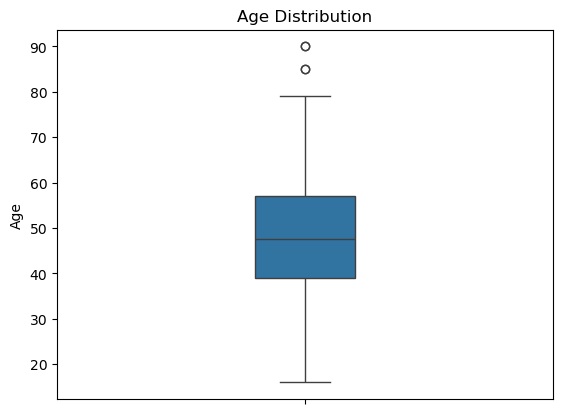

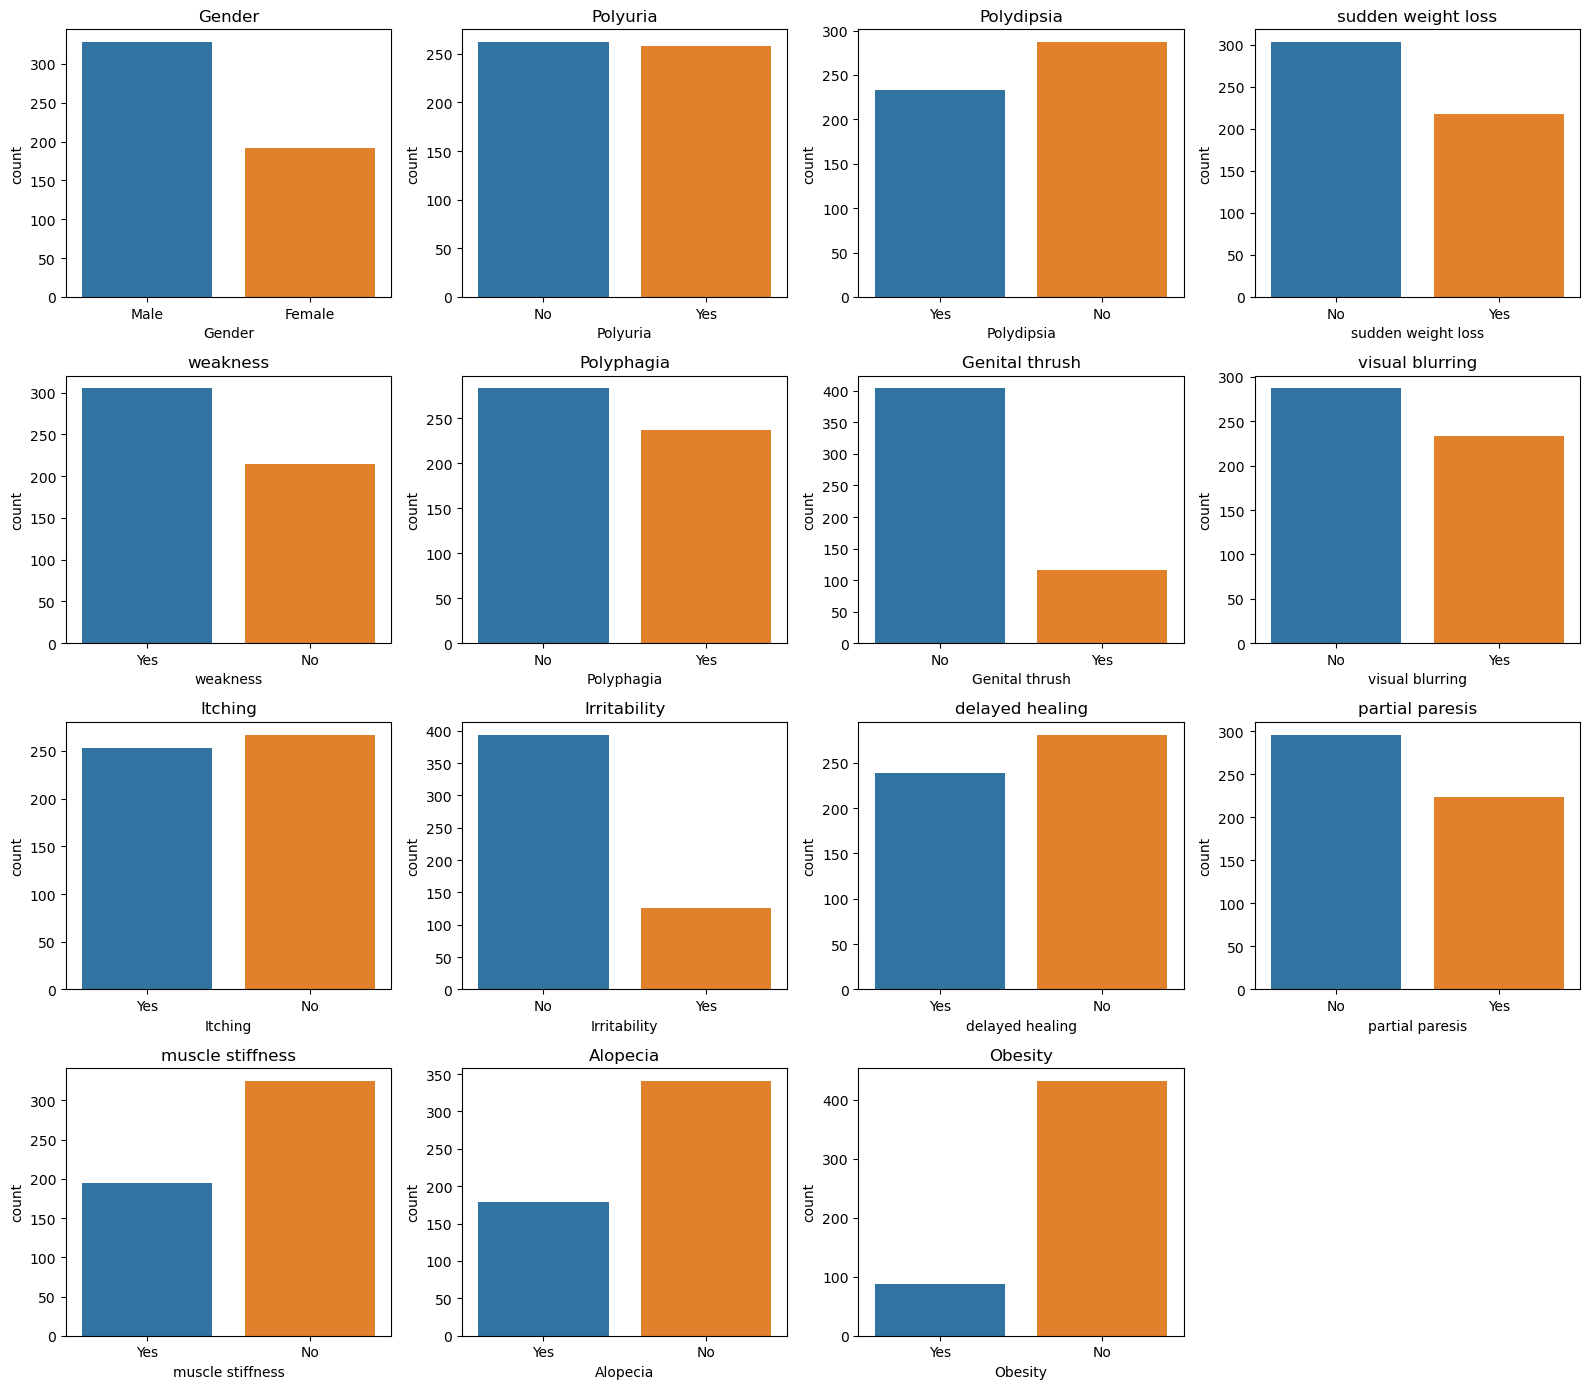

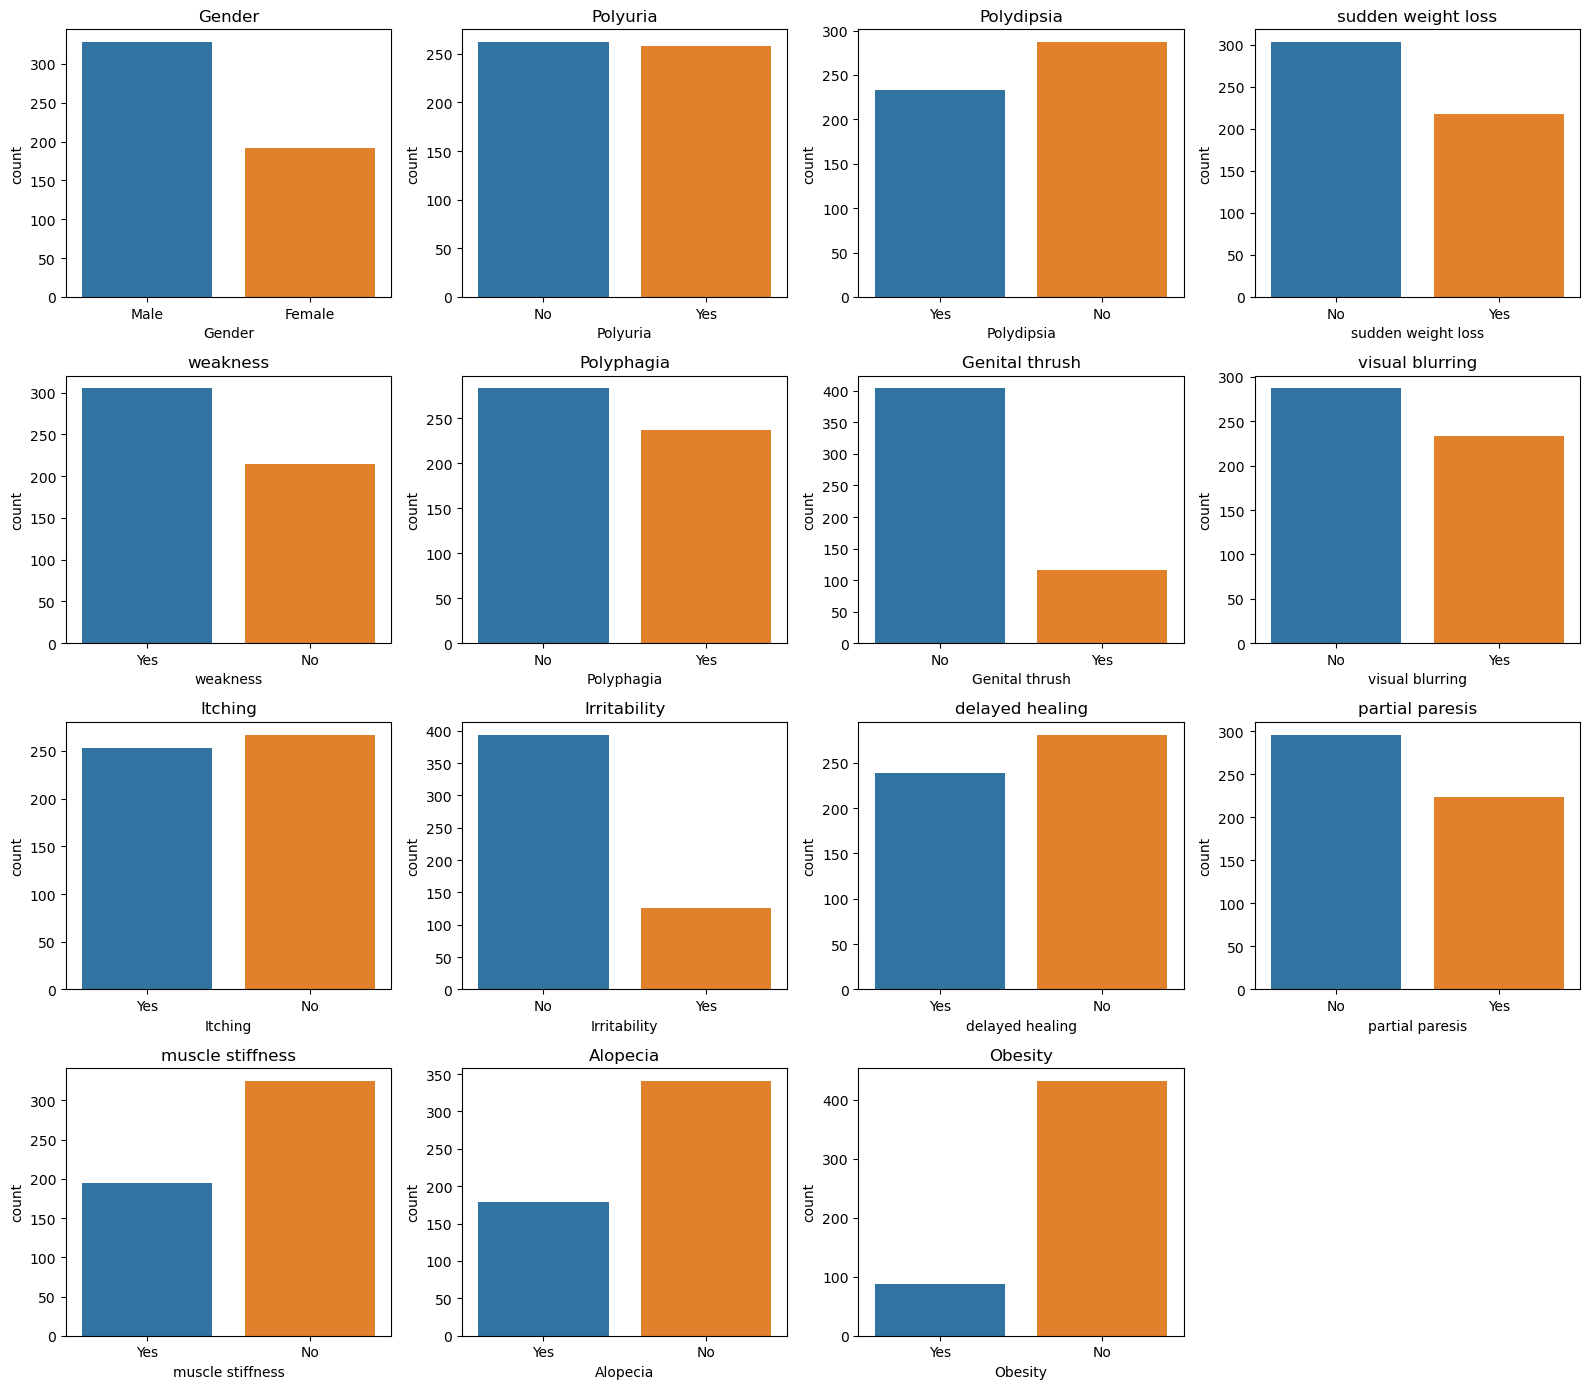

In [ ]:
## Understanding distribution of features

## Age distribution (only numeric feature)
sns.boxplot(y=df['Age'], width=0.2)
plt.title("Age Distribution")

plt.show()


plt.figure(fig)

## Categorical (symptom) features distribution
cat_cols = ['Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness',
            'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching',
            'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 
            'Alopecia', 'Obesity']

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, hue=col, legend=False, ax=axes[i])
    axes[i].set_title(col)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


### 2.3.2 Understanding relationship between variables

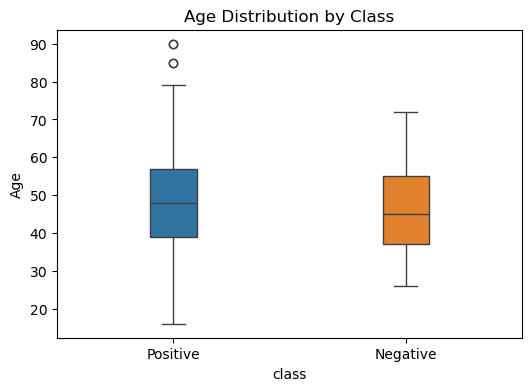

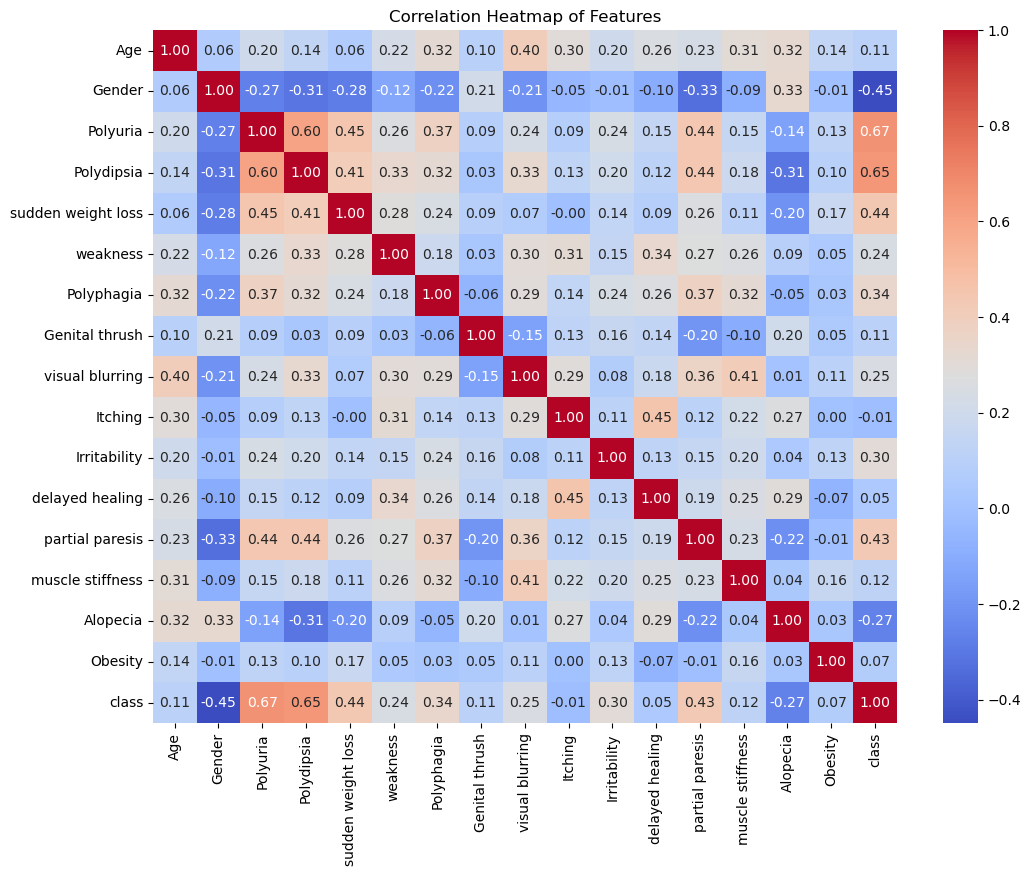

class                 1.000000
Polyuria              0.665922
Polydipsia            0.648734
sudden weight loss    0.436568
partial paresis       0.432288
Polyphagia            0.342504
Irritability          0.299467
visual blurring       0.251300
weakness              0.243275
muscle stiffness      0.122474
Genital thrush        0.110288
Age                   0.108679
Obesity               0.072173
delayed healing       0.046980
Itching              -0.013384
Alopecia             -0.267512
Gender               -0.449233
Name: class, dtype: float64


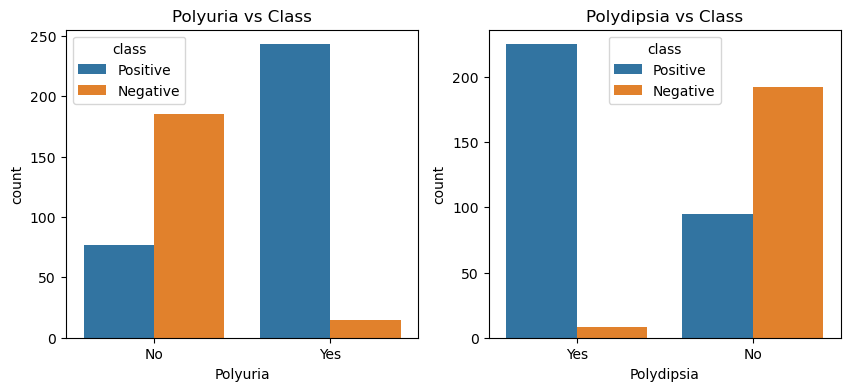

In [40]:
## Understanding relationship between variables

## Age vs class
plt.figure(figsize=(6,4))
sns.boxplot(x='class', y='Age', data=df, hue='class', width=0.2)
plt.title('Age Distribution by Class')
plt.show()

## Encode categorical Yes/No and Gender columns to numeric for correlation analysis
df_corr = df.copy()
binary_cols = [c for c in df_corr.columns if c not in ['Age', 'Gender']]
for col in binary_cols:
    df_corr[col] = df_corr[col].map({'Yes': 1, 'No': 0, 'Positive': 1, 'Negative': 0})
df_corr['Gender'] = df_corr['Gender'].map({'Male': 1, 'Female': 0})

plt.figure(figsize=(12,9))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap of Features')
plt.show()

## Correlation of each feature with target class, sorted
print(df_corr.corr()['class'].sort_values(ascending=False))

## Polyuria and Polydipsia vs class (top correlated symptoms)
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.countplot(x='Polyuria', hue='class', data=df, ax=axes[0])
axes[0].set_title('Polyuria vs Class')
sns.countplot(x='Polydipsia', hue='class', data=df, ax=axes[1])
axes[1].set_title('Polydipsia vs Class')
plt.show()

## 


# 3. Data Preparation

## 3.1 Data Cleaning

In [ ]:
## Clean data

## One Hot Encoding
pd.get_dummies(df, 
               columns=['Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness',
            'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching',
            'Irritability', 'delayed healing', 'partial paresis',
            'muscle stiffness', 'Alopecia', 'Obesity'], 
               drop_first=True 
               )



,Age,class,Gender_Male,Polyuria_Yes,Polydipsia_Yes,sudden weight loss_Yes,weakness_Yes,Polyphagia_Yes,Genital thrush_Yes,visual blurring_Yes,Itching_Yes,Irritability_Yes,delayed healing_Yes,partial paresis_Yes,muscle stiffness_Yes,Alopecia_Yes,Obesity_Yes
0,40,Positive,True,False,True,False,True,False,False,False,True,False,True,False,True,True,True
1,58,Positive,True,False,False,False,True,False,False,True,False,False,False,True,False,True,False
2,41,Positive,True,True,False,False,True,True,False,False,True,False,True,False,True,True,False
3,45,Positive,True,False,False,True,True,True,True,False,True,False,True,False,False,False,False
4,60,Positive,True,True,True,True,True,True,False,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,Positive,False,True,True,True,False,True,False,False,True,False,True,True,False,False,False
516,48,Positive,False,True,True,True,True,True,False,False,True,True,True,True,False,False,False
517,58,Positive,False,True,True,True,True,True,False,True,False,False,False,True,True,False,True
518,32,Negative,False,False,False,False,True,False,False,True,True,False,True,False,False,True,False


## 3.2 Train-Test Split

In [10]:
## Split data into train set and test set


# 4. Modelling

### 4.2 Train Model

In [11]:
## Initialise and train model


# 5. Model Evaluation

In [12]:
## Evaluate model


In [13]:
## New data

## Predict


## Iterative model development


In [14]:
## Further feature engineering / feature selection